# COL Transect Maps 2026

In [ ]:
#created a new conda env and loaded ggmap into it on terminal first
conda create --prefix /work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/.conda/envs/r-ggmap
conda activate /work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/.conda/envs/r-ggmap
conda install conda-forge::r-ggmap
conda install jupyter
conda install -c conda-forge r-irkernel
conda install -c conda-forge r-tidyverse

In [1]:
install.packages("plyr")
install.packages("tidyverse")
install.packages("reshape2")
install.packages("ggplot2")
install.packages("RColorBrewer")
install.packages("stringr")
install.packages("nloptr")
install.packages("car")
install.packages("ggmap")
install.packages("sp")
install.packages("ggrepel")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

also installing the dependency ‘lubridate’


Warning message in install.packages("tidyverse"):
“installation of package ‘lubridate’ had non-zero exit status”
Warning message in install.packages("tidyverse"):
“installation of package ‘tidyverse’ had non-zero exit status”
Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

also installing the dependencies ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, 

In [10]:
install.packages("dplyr")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [1]:
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
library(nlme)
library(plyr)
#library(car)
library(tidyverse)
library(reshape2) 
library(ggmap)
library(sp)
library(ggrepel)
library(ggplot2)
library(RColorBrewer)


Attaching package: ‘nlme’


The following object is masked from ‘package:dplyr’:

    collapse


------------------------------------------------------------------------------

You have loaded plyr after dplyr - this is likely to cause problems.
If you need functions from both plyr and dplyr, please load plyr first, then dplyr:
library(plyr); library(dplyr)

------------------------------------------------------------------------------


Attaching package: ‘plyr’


The following objects are masked from ‘package:dplyr’:

    arrange, count, desc, mutate, rename, summarise, summarize


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ readr     2.2.0
✔ ggplot2   4.0.2     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ plyr::arrange()   masks dplyr::arrange()
✖ nlme::collapse()  masks dplyr::collapse()

In [3]:
getwd()

[1] "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL_Maps"

In [4]:
corals <- read_csv("SAN_ColonyData.csv")

Rows: 171 Columns: 26
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (20): Date_InitialTag, Transect, Species, Direction, Antibiotic_Treatmen...
dbl  (6): TransectNum, TagNum, Meter, Meters_90, MaxDiameter_cm, MaxHeight_cm

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [5]:
head(corals)

Date_InitialTag,Transect,TransectNum,TagNum,Species,Meter,Meters_90,Direction,MaxDiameter_cm,MaxHeight_cm,⋯,032024_Condition,032024_Percentage,062024_Condition,062024_Percentage,092024_Condition,092024_Percentage,092024_Notes,012025_Condition,012025_Percentage,012025_Notes
<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
3/6/24,PLAZADETOROS,4,49,DLAB,2.0,1.0,R,30,5,⋯,Healthy,NA,Diseased,40%,Diseased,10%,NA,Healthy,NA,NA
3/6/24,PLAZADETOROS,4,68,DLAB,3.1,2.3,L,14,5,⋯,CLP,100,Healthy,NA,Diseased,10%,NA,Healthy,NA,NA
3/6/24,PLAZADETOROS,4,51,DLAB,1.0,7.6,R,16,10,⋯,CLP,80,Healthy,NA,Diseased,15%,NA,Healthy,NA,NA
3/6/24,PLAZADETOROS,4,67,PSTR,14.5,8.4,L,20,9,⋯,Healthy,NA,Healthy,NA,Diseased,15%,NA,Healthy,NA,NA
3/6/24,PLAZADETOROS,4,91,OFRA,24.8,5.9,L,118,14,⋯,Healthy,NA,CLP,15%,CLP,40%,NA,Healthy,NA,NA
3/6/24,PLAZADETOROS,4,24,MCAV,30.3,2.0,R,30,19,⋯,Healthy,NA,Healthy,NA,DC,50%,NA,Healthy,NA,NA


In [6]:
corals$Direction <- dplyr::recode(corals$Direction, "L" = "left",
                                  "R" = "right")

In [7]:
sapply(corals, class)

Date_InitialTag                           Transect 
                       "character"                        "character" 
                       TransectNum                             TagNum 
                         "numeric"                          "numeric" 
                           Species                              Meter 
                       "character"                          "numeric" 
                         Meters_90                          Direction 
                         "numeric"                        "character" 
                    MaxDiameter_cm                       MaxHeight_cm 
                         "numeric"                          "numeric" 
              Antibiotic_Treatment Date_Documented_Probiotic_Sampling 
                       "character"                        "character" 
            Date_DocumentedDisease           Date_DocumentedMortality 
                       "character"                        "character" 
                      Notes_032024                       Notes_062024 
                       "character"                        "character" 
                  032024_Condition                  032024_Percentage 
                       "character"                        "character" 
                  062024_Condition                  062024_Percentage 
                       "character"                        "character" 
                  092024_Condition                  092024_Percentage 
                       "character"                        "character" 
                      092024_Notes                   012025_Condition 
                       "character"                        "character" 
                 012025_Percentage                       012025_Notes 
                       "character"                        "character"

In [8]:
# View the 'Meters_90' column
corals[order(corals$Meters_90),]

Date_InitialTag,Transect,TransectNum,TagNum,Species,Meter,Meters_90,Direction,MaxDiameter_cm,MaxHeight_cm,⋯,032024_Condition,032024_Percentage,062024_Condition,062024_Percentage,092024_Condition,092024_Percentage,092024_Notes,012025_Condition,012025_Percentage,012025_Notes
<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
3/6/24,PLAZADETOROS,4,92,OFAV,24.7,0.00,left,55.0,39,⋯,Healthy,NA,Diseased,NA,Diseased,NA,may be predation,Healthy,NA,NA
3/6/24,PLAZADETOROS,4,93,OFAV,33.4,0.00,left,130.0,65,⋯,Healthy,NA,Diseased,50%,Diseased,NA,NA,CLP,100%,NA
3/2/24,NIRVANA,1,51,PSTR,20.0,0.00,left,210.0,5,⋯,Healthy,NA,Healthy,NA,NA,NA,NA,Healthy,NA,NA
3/4/24,PUNTAPADI,2,93,DLAB,23.5,0.00,left,18.0,8,⋯,Healthy,NA,Diseased,5%,NA,NA,NA,Healthy,NA,NA
3/4/24,PUNTAPADI,2,39,MCAV,1.5,0.00,right,37.0,31,⋯,Healthy,NA,NA,NA,NA,NA,NA,CLP,100%,"No tag found, old mort"
3/4/24,PUNTAPADI,2,40,MCAV,3.2,0.00,left,43.0,20,⋯,Diseased,15,Healthy,NA,NA,NA,NA,CLP,100%,Old mort
3/5/24,ROCOSA,3,60,OFAV,13.6,0.00,left,2.7,60,⋯,Healthy,NA,CLP,NA,NA,NA,NA,Diseased,NA,NA
3/7/24,ELARBOL,5,25,OFAV,28.9,0.00,left,282.0,110,⋯,Healthy,NA,Dead,NA,NA,NA,NA,Dead,NA,NA
3/5/24,ROCOSA,3,33,CNAT,7.7,0.20,left,65.0,35,⋯,Healthy,NA,Healthy,NA,NA,NA,NA,Healthy,NA,NA


In [9]:
# List columns in the data frame
colnames(corals)

[1] "Date_InitialTag"                    "Transect"                          
 [3] "TransectNum"                        "TagNum"                            
 [5] "Species"                            "Meter"                             
 [7] "Meters_90"                          "Direction"                         
 [9] "MaxDiameter_cm"                     "MaxHeight_cm"                      
[11] "Antibiotic_Treatment"               "Date_Documented_Probiotic_Sampling"
[13] "Date_DocumentedDisease"             "Date_DocumentedMortality"          
[15] "Notes_032024"                       "Notes_062024"                      
[17] "032024_Condition"                   "032024_Percentage"                 
[19] "062024_Condition"                   "062024_Percentage"                 
[21] "092024_Condition"                   "092024_Percentage"                 
[23] "092024_Notes"                       "012025_Condition"                  
[25] "012025_Percentage"                  "012025_Notes"

In [10]:
corals <- corals %>% mutate(Meters_90 = ifelse(Direction == "left",
                                               -Meters_90, Meters_90)) %>%
  mutate(Condition = ifelse(Date_DocumentedMortality != "Healthy"& Date_DocumentedMortality != "Diseased",
                            "Dead", Date_DocumentedMortality)) %>%
  mutate(MaxDiameter = ifelse(is.na(MaxDiameter_cm),
                              40, MaxDiameter_cm))

In [11]:
specalpha = c('Dead'= 1,'Diseased'= 0,'Healthy'= 0)

speccolors = c('SSID'='red3','MCAV'='darkorchid4','PAST'='orange',
              'MMEA' = 'black', 'PSTR' ='green4', 
              'CNAT' = 'lightgoldenrod', 'OFAV' = 'pink', 'OFRA' = 'lightcyan',
              'DLAB' = 'tan4')

In [12]:
corals$MaxDiameter <- as.numeric(corals$MaxDiameter)
corals$Condition <- as.factor(corals$Condition)

In [13]:
corals[, c("TagNum", "Transect", "Species", "Condition")]

TagNum,Transect,Species,Condition
<dbl>,<chr>,<chr>,<fct>
49,PLAZADETOROS,DLAB,Healthy
68,PLAZADETOROS,DLAB,Healthy
51,PLAZADETOROS,DLAB,Healthy
67,PLAZADETOROS,PSTR,Healthy
91,PLAZADETOROS,OFRA,Healthy
24,PLAZADETOROS,MCAV,Healthy
55,PLAZADETOROS,PSTR,Healthy
64,PLAZADETOROS,DLAB,Dead
65,PLAZADETOROS,DLAB,Dead


In [14]:
unique(corals$Transect)

[1] "PLAZADETOROS" "NIRVANA"      "PUNTAPADI"    "ROCOSA"       "ELARBOL"

In [15]:
unique(corals$Species)

[1] "DLAB" "PSTR" "OFRA" "MCAV" "CNAT" "OFAV"

not worrying about probiotic corals this time (ignored probiotic specific code in from 2024 notebook)

## EL ARBOL

In [16]:
ELARBOL <- corals %>% subset(Transect == "ELARBOL") %>%
  subset(!(is.na(TagNum)))

In [17]:
head(ELARBOL)

Date_InitialTag,Transect,TransectNum,TagNum,Species,Meter,Meters_90,Direction,MaxDiameter_cm,MaxHeight_cm,⋯,062024_Condition,062024_Percentage,092024_Condition,092024_Percentage,092024_Notes,012025_Condition,012025_Percentage,012025_Notes,Condition,MaxDiameter
<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<dbl>
3/7/24,ELARBOL,5,81,DLAB,13.0,-2.0,left,40,30,⋯,Healthy,NA,NA,NA,NA,Healthy,NA,NA,Healthy,40
3/7/24,ELARBOL,5,83,DLAB,12.4,8.0,right,15,2,⋯,Healthy,NA,NA,NA,NA,Not_found,NA,NA,Healthy,15
3/7/24,ELARBOL,5,86,DLAB,28.5,4.4,right,36,27,⋯,Healthy,NA,NA,NA,NA,Healthy,NA,NA,Healthy,36
3/7/24,ELARBOL,5,87,DLAB,38.3,8.0,right,10,12,⋯,Healthy,NA,NA,NA,NA,Healthy,NA,NA,Healthy,10
3/7/24,ELARBOL,5,88,DLAB,38.3,8.0,right,27,15,⋯,Healthy,NA,NA,NA,NA,Healthy,NA,NA,Healthy,27
3/7/24,ELARBOL,5,94,DLAB,47.8,-5.0,left,19,10,⋯,Healthy,NA,NA,NA,NA,Healthy,NA,NA,Healthy,19


In [18]:
# set max and min of y axis to longest points on the transect
max_y <- max(ELARBOL$Meter)
print(max_y)
min_y <- min(ELARBOL$Meter)
print(min_y)

[1] 48.5
[1] 0


In [19]:
# set max and min of x axis to longest points on the transect L to R
max_x <- max(ELARBOL$Meters_90)
print(max_x)
min_x <- min(ELARBOL$Meters_90)
print(min_x)

[1] 13
[1] -9.2


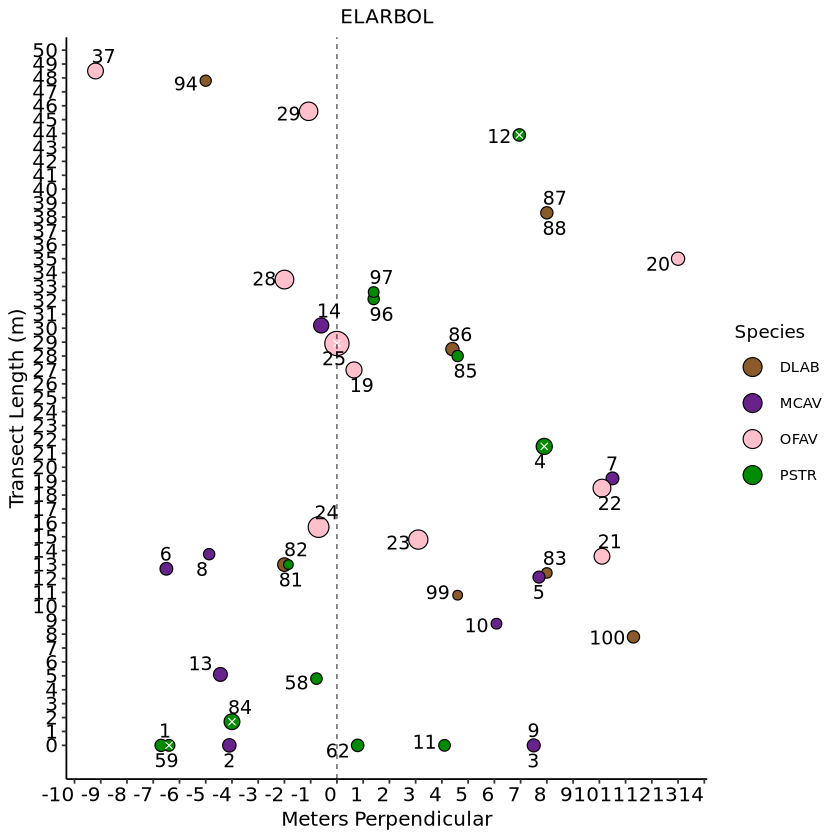

In [20]:
ggplot() +
  geom_point(data = ELARBOL, aes(x = Meters_90, y = Meter, fill = Species, size = MaxDiameter), shape = 21) +
  scale_fill_manual(values = c(speccolors), guide = guide_legend(override.aes = list(pch = 21, size = 5))) +
  geom_point(data = ELARBOL, aes(x = Meters_90, y = Meter, alpha = Condition), pch = 4, color = "snow", stroke = 0.5) +
  geom_vline(xintercept = 0, lty = 2, lwd = 0.25) +
  geom_text_repel(data = ELARBOL, aes(x = Meters_90, y = Meter, label = TagNum), max.overlaps = 20, color = "black", size = 4, hjust = -0.2) +
  scale_y_continuous("Transect Length (m)", breaks = seq(0, 50, by = 1)) +
  scale_x_continuous("Meters Perpendicular", breaks = seq(-15, 15, by = 1)) +
  scale_size_continuous(range = c(2, 6.5), name = "", guide = 'none') +
  scale_alpha_manual(values = c(specalpha), guide = 'none') +
  ggtitle("ELARBOL") +
  theme(plot.title = element_text(size = 12, hjust = 0.5),
        panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(colour = "black", hjust = 1, size = 12),
        axis.title = element_text(size = 12),
        legend.key.size = unit(1.5, "line"))

In [21]:
tiff("ELARBOL_color.tif", width = 10, height = 10, units = "in", res = 300)  # Adjust width and height
ggplot() +  
  geom_point(data = ELARBOL, aes(x = Meters_90, y = Meter, fill = Species, size = MaxDiameter), shape = 21) +
  scale_fill_manual(values = c(speccolors), guide = guide_legend(override.aes = list(pch = 21, size = 5))) +
  geom_point(data = ELARBOL, aes(x = Meters_90, y = Meter, alpha = Condition), pch = 4, color = "snow", stroke = 0.5) +
  geom_vline(xintercept = 0, lty = 2, lwd = 0.25) +
  geom_text_repel(data = ELARBOL, aes(x = Meters_90, y = Meter, label = TagNum), max.overlaps = 20, color = "black", size = 4, hjust = -0.2) +
  scale_y_continuous("Transect Length (m)", breaks = seq(0, 50, by = 1)) +
  scale_x_continuous("Meters Perpendicular", breaks = seq(-15, 15, by = 1)) +
  scale_size_continuous(range = c(2, 6.5), name = "", guide = 'none') +
  scale_alpha_manual(values = c(specalpha), guide = 'none') +
  ggtitle("ELARBOL") +
  theme(plot.title = element_text(size = 12, hjust = 0.5),
        panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(colour = "black", hjust = 1, size = 11),
        axis.title = element_text(size = 12),
        legend.key.size = unit(1.5, "line"))
dev.off()

agg_record_255352881 
                   2

## PLAZADETOROS

In [22]:
PLAZADETOROS <- corals %>% subset(Transect == "PLAZADETOROS") %>%
  subset(!(is.na(TagNum)))

In [23]:
# set max and min of y axis to longest points on the transect
max_y <- max(PLAZADETOROS$Meter)
print(max_y)
min_y <- min(PLAZADETOROS$Meter)
print(min_y)

[1] 53
[1] 1


In [24]:
# set max and min of x axis to longest points on the transect L to R
max_x <- max(PLAZADETOROS$Meters_90)
print(max_x)
min_x <- min(PLAZADETOROS$Meters_90)
print(min_x)

[1] 18
[1] -18


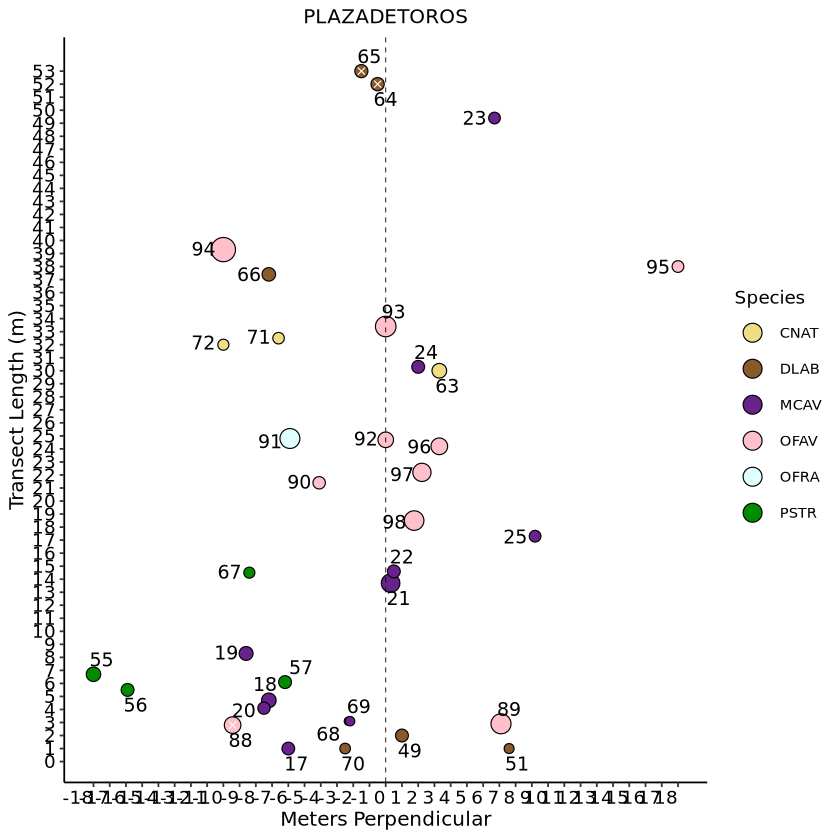

In [25]:
ggplot() +
  geom_point(data = PLAZADETOROS, aes(x = Meters_90, y = Meter, fill = Species, size = MaxDiameter), shape = 21) +
  scale_fill_manual(values = c(speccolors), guide = guide_legend(override.aes = list(pch = 21, size = 5))) +
  geom_point(data = PLAZADETOROS, aes(x = Meters_90, y = Meter, alpha = Condition), pch = 4, color = "snow", stroke = 0.5) +
  geom_vline(xintercept = 0, lty = 2, lwd = 0.25) +
  geom_text_repel(data = PLAZADETOROS, aes(x = Meters_90, y = Meter, label = TagNum), max.overlaps = 20, color = "black", size = 4, hjust = -0.2) +
  scale_y_continuous("Transect Length (m)", breaks = seq(0, 53, by = 1)) +
  scale_x_continuous("Meters Perpendicular", breaks = seq(-18, 18, by = 1)) +
  scale_size_continuous(range = c(2, 6.5), name = "", guide = 'none') +
  scale_alpha_manual(values = c(specalpha), guide = 'none') +
  ggtitle("PLAZADETOROS") +
  theme(plot.title = element_text(size = 12, hjust = 0.5),
        panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(colour = "black", hjust = 1, size = 11),
        axis.title = element_text(size = 12),
        legend.key.size = unit(1.5, "line"))

In [43]:
tiff("PLAZADETOROS_color_1.tif", width = 12, height = 10, units = "in", res = 300)  # Adjust width and height
ggplot() +
  geom_point(data = PLAZADETOROS, aes(x = Meters_90, y = Meter, fill = Species, size = MaxDiameter), shape = 21) +
  scale_fill_manual(values = c(speccolors), guide = guide_legend(override.aes = list(pch = 21, size = 5))) +
  geom_point(data = PLAZADETOROS, aes(x = Meters_90, y = Meter, alpha = Condition), pch = 4, color = "snow", stroke = 0.5) +
  geom_vline(xintercept = 0, lty = 2, lwd = 0.25) +
  geom_text_repel(data = PLAZADETOROS, aes(x = Meters_90, y = Meter, label = TagNum), max.overlaps = 20, color = "black", size = 4, hjust = -0.2) +
  scale_y_continuous("Transect Length (m)", breaks = seq(0, 53, by = 1)) +
  scale_x_continuous("Meters Perpendicular", breaks = seq(-18, 18, by = 1)) +
  scale_size_continuous(range = c(2, 6.5), name = "", guide = 'none') +
  scale_alpha_manual(values = c(specalpha), guide = 'none') +
  ggtitle("PLAZADETOROS") +
  theme(plot.title = element_text(size = 12, hjust = 0.5),
        panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(colour = "black", hjust = 1, size = 11),
        axis.title = element_text(size = 12),
        legend.key.size = unit(1.5, "line"))
dev.off()

agg_record_588945013 
                   2

## ROCOSA

In [27]:
ROCOSA <- corals %>% subset(Transect == "ROCOSA") %>%
  subset(!(is.na(TagNum)))

In [28]:
# set max and min of y axis to longest points on the transect
max_y <- round(max(ROCOSA$Meter))
print(max_y)
min_y <- round(min(ROCOSA$Meter))
print(min_y)

[1] 48
[1] -5


In [29]:
# set max and min of x axis to longest points on the transect L to R
max_x <- round(max(ROCOSA$Meters_90))
print(max_x)
min_x <- round(min(ROCOSA$Meters_90))
print(min_x)

[1] 10
[1] -17


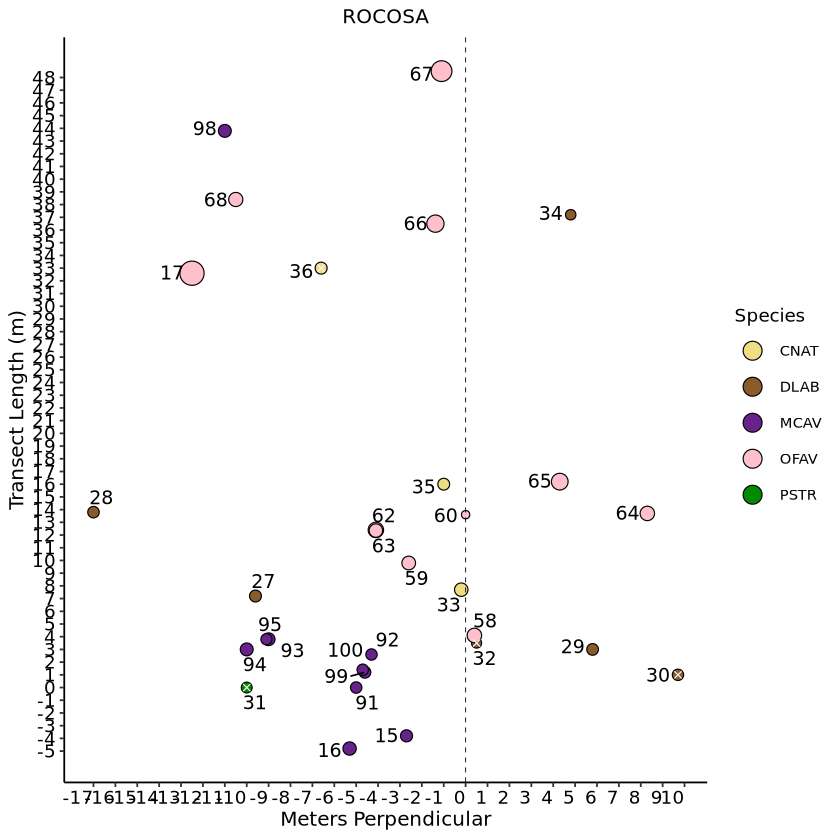

In [30]:
ggplot() +
  geom_point(data = ROCOSA, aes(x = Meters_90, y = Meter, fill = Species, size = MaxDiameter), shape = 21) +
  scale_fill_manual(values = c(speccolors), guide = guide_legend(override.aes = list(pch = 21, size = 5))) +
  geom_point(data = ROCOSA, aes(x = Meters_90, y = Meter, alpha = Condition), pch = 4, color = "snow", stroke = 0.5) +
  geom_vline(xintercept = 0, lty = 2, lwd = 0.25) +
  geom_text_repel(data = ROCOSA, aes(x = Meters_90, y = Meter, label = TagNum), max.overlaps = 20, color = "black", size = 4, hjust = -0.2) +
  scale_y_continuous("Transect Length (m)", breaks = seq(-5, 48, by = 1)) +
  scale_x_continuous("Meters Perpendicular", breaks = seq(-17, 10, by = 1)) +
  scale_size_continuous(range = c(2, 6.5), name = "", guide = 'none') +
  scale_alpha_manual(values = c(specalpha), guide = 'none') +
  ggtitle("ROCOSA") +
  theme(plot.title = element_text(size = 12, hjust = 0.5),
        panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(colour = "black", hjust = 1, size = 11),
        axis.title = element_text(size = 12),
        legend.key.size = unit(1.5, "line"))

In [31]:
tiff("ROCOSA_color.tif", width = 10, height = 10, units = "in", res = 300)  # Adjust width and height
ggplot() +
  geom_point(data = ROCOSA, aes(x = Meters_90, y = Meter, fill = Species, size = MaxDiameter), shape = 21) +
  scale_fill_manual(values = c(speccolors), guide = guide_legend(override.aes = list(pch = 21, size = 5))) +
  geom_point(data = ROCOSA, aes(x = Meters_90, y = Meter, alpha = Condition), pch = 4, color = "snow", stroke = 0.5) +
  geom_vline(xintercept = 0, lty = 2, lwd = 0.25) +
  geom_text_repel(data = ROCOSA, aes(x = Meters_90, y = Meter, label = TagNum), max.overlaps = 20, color = "black", size = 4, hjust = -0.2) +
  scale_y_continuous("Transect Length (m)", breaks = seq(-5, 48, by = 1)) +
  scale_x_continuous("Meters Perpendicular", breaks = seq(-17, 10, by = 1)) +
  scale_size_continuous(range = c(2, 6.5), name = "", guide = 'none') +
  scale_alpha_manual(values = c(specalpha), guide = 'none') +
  ggtitle("ROCOSA") +
  theme(plot.title = element_text(size = 12, hjust = 0.5),
        panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(colour = "black", hjust = 1, size = 11),
        axis.title = element_text(size = 12),
        legend.key.size = unit(1.5, "line"))
dev.off()

agg_record_811248220 
                   2

## NIRVANA

In [32]:
NIRVANA <- corals %>% subset(Transect == "NIRVANA") %>%
  subset(!(is.na(TagNum)))

In [33]:
# set max and min of y axis to longest points on the transect
max_y <- round(max(NIRVANA$Meter))
print(max_y)
min_y <- round(min(NIRVANA$Meter))
print(min_y)

[1] 44
[1] 0


In [34]:
# set max and min of x axis to longest points on the transect L to R
max_x <- round(max(NIRVANA$Meters_90))
print(max_x)
min_x <- round(min(NIRVANA$Meters_90))
print(min_x)

[1] 22
[1] -12


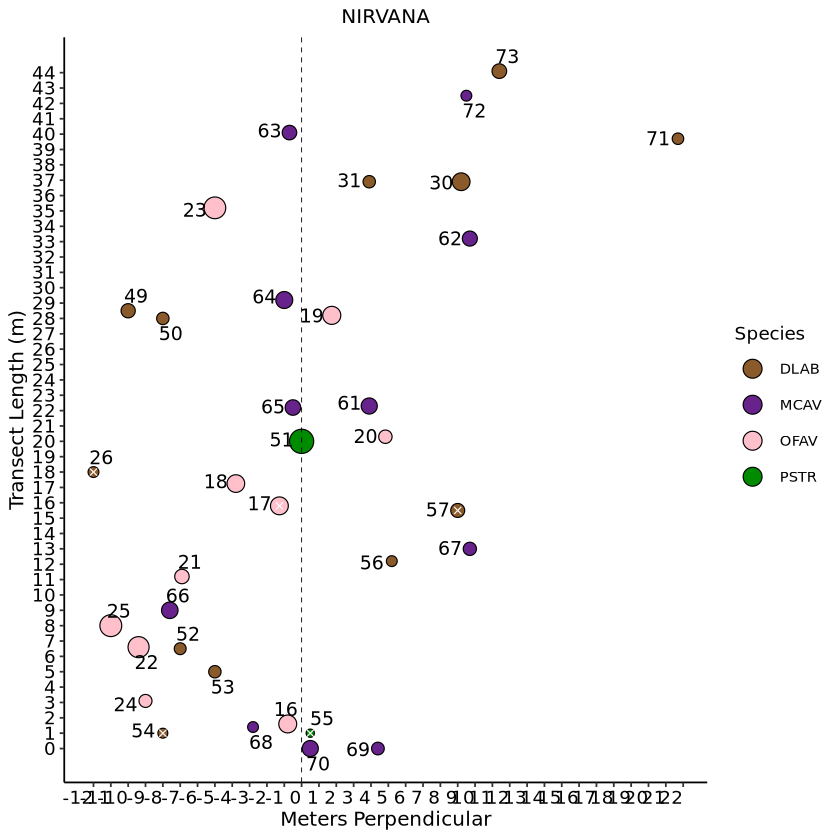

In [35]:
ggplot() +
  geom_point(data = NIRVANA, aes(x = Meters_90, y = Meter, fill = Species, size = MaxDiameter), shape = 21) +
  scale_fill_manual(values = c(speccolors), guide = guide_legend(override.aes = list(pch = 21, size = 5))) +
  geom_point(data = NIRVANA, aes(x = Meters_90, y = Meter, alpha = Condition), pch = 4, color = "snow", stroke = 0.5) +
  geom_vline(xintercept = 0, lty = 2, lwd = 0.25) +
  geom_text_repel(data = NIRVANA, aes(x = Meters_90, y = Meter, label = TagNum), max.overlaps = 20, color = "black", size = 4, hjust = -0.2) +
  scale_y_continuous("Transect Length (m)", breaks = seq(0, 44, by = 1)) +
  scale_x_continuous("Meters Perpendicular", breaks = seq(-12, 22, by = 1)) +
  scale_size_continuous(range = c(2, 6.5), name = "", guide = 'none') +
  scale_alpha_manual(values = c(specalpha), guide = 'none') +
  ggtitle("NIRVANA") +
  theme(plot.title = element_text(size = 12, hjust = 0.5),
        panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(colour = "black", hjust = 1, size = 11),
        axis.title = element_text(size = 12),
        legend.key.size = unit(1.5, "line"))

In [36]:
tiff("NIRVANA_color.tif", width = 12, height = 10, units = "in", res = 300)
ggplot() +
  geom_point(data = NIRVANA, aes(x = Meters_90, y = Meter, fill = Species, size = MaxDiameter), shape = 21) +
  scale_fill_manual(values = c(speccolors), guide = guide_legend(override.aes = list(pch = 21, size = 5))) +
  geom_point(data = NIRVANA, aes(x = Meters_90, y = Meter, alpha = Condition), pch = 4, color = "snow", stroke = 0.5) +
  geom_vline(xintercept = 0, lty = 2, lwd = 0.25) +
  geom_text_repel(data = NIRVANA, aes(x = Meters_90, y = Meter, label = TagNum), max.overlaps = 20, color = "black", size = 4, hjust = -0.2) +
  scale_y_continuous("Transect Length (m)", breaks = seq(0, 44, by = 1)) +
  scale_x_continuous("Meters Perpendicular", breaks = seq(-12, 22, by = 1)) +
  scale_size_continuous(range = c(2, 6.5), name = "", guide = 'none') +
  scale_alpha_manual(values = c(specalpha), guide = 'none') +
  ggtitle("NIRVANA") +
  theme(plot.title = element_text(size = 12, hjust = 0.5),
        panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(colour = "black", hjust = 1, size = 11),
        axis.title = element_text(size = 12),
        legend.key.size = unit(1.5, "line"))
dev.off()

agg_record_310188096 
                   2

## PUNTAPADI

In [37]:
PUNTAPADI <- corals %>% subset(Transect == "PUNTAPADI") %>%
  subset(!(is.na(TagNum)))

In [38]:
# set max and min of y axis to longest points on the transect
max_y <- round(max(PUNTAPADI$Meter))
print(max_y)
min_y <- round(min(PUNTAPADI$Meter))
print(min_y)

[1] 39
[1] 0


In [39]:
# set max and min of x axis to longest points on the transect L to R
max_x <- round(max(PUNTAPADI$Meters_90))
print(max_x)
min_x <- round(min(PUNTAPADI$Meters_90))
print(min_x)

[1] 10
[1] -8


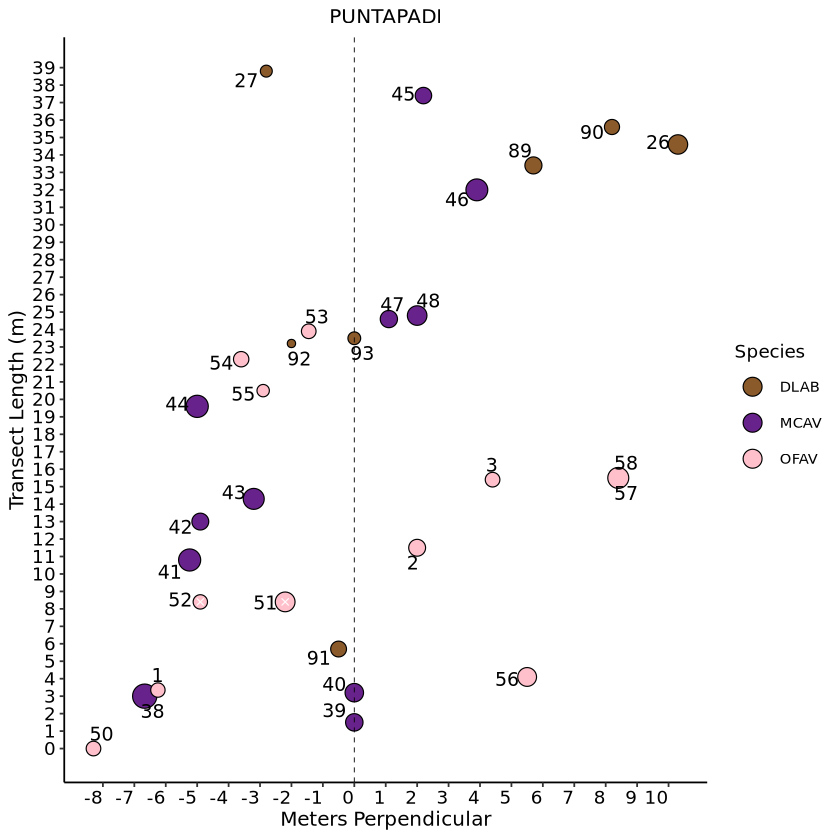

In [40]:
ggplot() +
  geom_point(data = PUNTAPADI, aes(x = Meters_90, y = Meter, fill = Species, size = MaxDiameter), shape = 21) +
  scale_fill_manual(values = c(speccolors), guide = guide_legend(override.aes = list(pch = 21, size = 5))) +
  geom_point(data = PUNTAPADI, aes(x = Meters_90, y = Meter, alpha = Condition), pch = 4, color = "snow", stroke = 0.5) +
  geom_vline(xintercept = 0, lty = 2, lwd = 0.25) +
  geom_text_repel(data = PUNTAPADI, aes(x = Meters_90, y = Meter, label = TagNum), max.overlaps = 20, color = "black", size = 4, hjust = -0.2) +
  scale_y_continuous("Transect Length (m)", breaks = seq(0, 39, by = 1)) +
  scale_x_continuous("Meters Perpendicular", breaks = seq(-8, 10, by = 1)) +
  scale_size_continuous(range = c(2, 6.5), name = "", guide = 'none') +
  scale_alpha_manual(values = c(specalpha), guide = 'none') +
  ggtitle("PUNTAPADI") +
  theme(plot.title = element_text(size = 12, hjust = 0.5),
        panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(colour = "black", hjust = 1, size = 11),
        axis.title = element_text(size = 12),
        legend.key.size = unit(1.5, "line"))

In [41]:
tiff("PUNTAPADI_color.tif", width = 8, height = 10, units = "in", res = 300)  # Adjust width and height
ggplot() +
  geom_point(data = PUNTAPADI, aes(x = Meters_90, y = Meter, fill = Species, size = MaxDiameter), shape = 21) +
  scale_fill_manual(values = c(speccolors), guide = guide_legend(override.aes = list(pch = 21, size = 5))) +
  geom_point(data = PUNTAPADI, aes(x = Meters_90, y = Meter, alpha = Condition), pch = 4, color = "snow", stroke = 0.5) +
  geom_vline(xintercept = 0, lty = 2, lwd = 0.25) +
  geom_text_repel(data = PUNTAPADI, aes(x = Meters_90, y = Meter, label = TagNum), max.overlaps = 20, color = "black", size = 4, hjust = -0.2) +
scale_y_continuous("Transect Length (m)", breaks = seq(0, 39, by = 1)) +
  scale_x_continuous("Meters Perpendicular", breaks = seq(-8, 10, by = 1)) +
  scale_size_continuous(range = c(2, 6.5), name = "", guide = 'none') +
  scale_alpha_manual(values = c(specalpha), guide = 'none') +
  ggtitle("PUNTAPADI") +
  theme(plot.title = element_text(size = 12, hjust = 0.5),
        panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(colour = "black", hjust = 1, size = 11),
        axis.title = element_text(size = 12),
        legend.key.size = unit(1.5, "line"))
dev.off()

agg_record_1331559736 
                    2

In [42]:
getwd()

[1] "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL_Maps"